<a href="https://colab.research.google.com/github/Nirjala7-11/UberRidesAnalysis/blob/main/UberRidesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Importing Logistic Regression Model
from sklearn.linear_model import LogisticRegression #Binary output
# Importing Accuarcy Score function
from sklearn.metrics import accuracy_score
# Importing train test split function
from sklearn.model_selection import train_test_split
# To convert all the strings format into numeric
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv('/content/drive/MyDrive/collab/ncr_ride_bookings.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df.shape

(150000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [7]:
#Checking Null values
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [8]:
df.dropna(how='all',inplace=True)

In [9]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [10]:
df['Vehicle Type']=df['Vehicle Type'].replace({'eBike':'E-Bike'})
df['Vehicle Type']=df['Vehicle Type'].replace({'Bike':'MotorBike'})
df['Vehicle Type']=df['Vehicle Type'].replace({'Auto':'Auto Rickshaw'})
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",E-Bike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto Rickshaw,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",MotorBike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto Rickshaw,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [11]:
#Replacing Null Values with mean of respective columns
ctat_mean=np.nanmean(df['Avg CTAT'])
vtat_mean=np.nanmean(df['Avg VTAT'])
bookval_mean=np.nanmean(df['Booking Value'])
ride_dis=np.nanmean(df['Ride Distance'])
drv_rtg=np.nanmean(df['Driver Ratings'])
cst_rtg=np.nanmean(df['Customer Rating'])


df['Avg CTAT']=df['Avg CTAT'].fillna(ctat_mean).round(2)
df['Avg VTAT']=df['Avg VTAT'].fillna(vtat_mean).round(2)
df['Booking Value']=df['Booking Value'].fillna(bookval_mean).round(2)
df['Ride Distance']=df['Ride Distance'].fillna(ride_dis).round(2)
df['Driver Ratings']=df['Driver Ratings'].fillna(drv_rtg).round(2)
df['Customer Rating']=df['Customer Rating'].fillna(cst_rtg).round(2)
df['Incomplete Rides']=df['Incomplete Rides'].fillna(0.0)
df['Cancelled Rides by Driver']=df['Cancelled Rides by Driver'].fillna('Unspecified')
df['Cancelled Rides by Customer']=df['Cancelled Rides by Customer'].fillna('Obscure')
df['Driver Cancellation Reason']=df['Driver Cancellation Reason'].fillna('Anonymus')
df['Reason for cancelling by Customer']=df['Reason for cancelling by Customer'].fillna('Unfamiliar')
df['Incomplete Rides Reason']=df['Incomplete Rides Reason'].fillna('Others')
df['Payment Method']=df['Payment Method'].fillna('NA')
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",E-Bike,Palam Vihar,Jhilmil,8.46,29.15,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,508.3,24.64,4.23,4.4,NA
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,...,Unfamiliar,Unspecified,Anonymus,1.0,Vehicle Breakdown,237.0,5.73,4.23,4.4,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto Rickshaw,Khandsa,Malviya Nagar,13.40,25.80,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,627.0,13.58,4.90,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10,28.50,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,416.0,34.02,4.60,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",MotorBike,Ghitorni Village,Khan Market,5.30,19.60,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,737.0,48.21,4.10,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.20,44.40,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,475.0,40.08,3.70,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.10,30.80,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,1093.0,21.31,4.80,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.70,23.40,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,852.0,15.93,3.90,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto Rickshaw,Ghaziabad,Saidulajab,6.90,39.60,...,Unfamiliar,Unspecified,Anonymus,0.0,Others,333.0,45.54,4.10,3.7,UPI


In [12]:
#Overview of booking status
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [13]:
#Calculating the total cancelled rides
ttl_cncld=df['Booking Status'].isin(['Cancelled by Driver','Cancelled by Customer']).sum()
ttl_rides=len(df['Booking Status'])

#Calculating percetage of cancelled rides
cncld_prcnt=(ttl_cncld/ttl_rides)*100
print(ttl_cncld)
print(ttl_rides)
print(cncld_prcnt)

37500
150000
25.0


In [14]:
#the Probability of a ride receiving a rating ≥ 4
ratings = df['Driver Ratings'].dropna()
total_rated = len(ratings)
print(total_rated, "rated trips")
prob_rating_4_or_above = (ratings >= 4).mean()
print(prob_rating_4_or_above)

150000 rated trips
0.85986


In [15]:
# Probability of changing a rating conditional on vehicle type
df_ratings = df[['Driver Ratings', 'Vehicle Type']].dropna()
prob_by_vehicle = (df_ratings.groupby('Vehicle Type')['Driver Ratings'].apply(lambda x: (x >= 4).mean()).sort_values(ascending=False))
print(prob_by_vehicle)

Vehicle Type
Uber XL          0.862666
Premier Sedan    0.861741
Go Sedan         0.861391
Auto Rickshaw    0.861354
MotorBike        0.858107
E-Bike           0.857914
Go Mini          0.857042
Name: Driver Ratings, dtype: float64


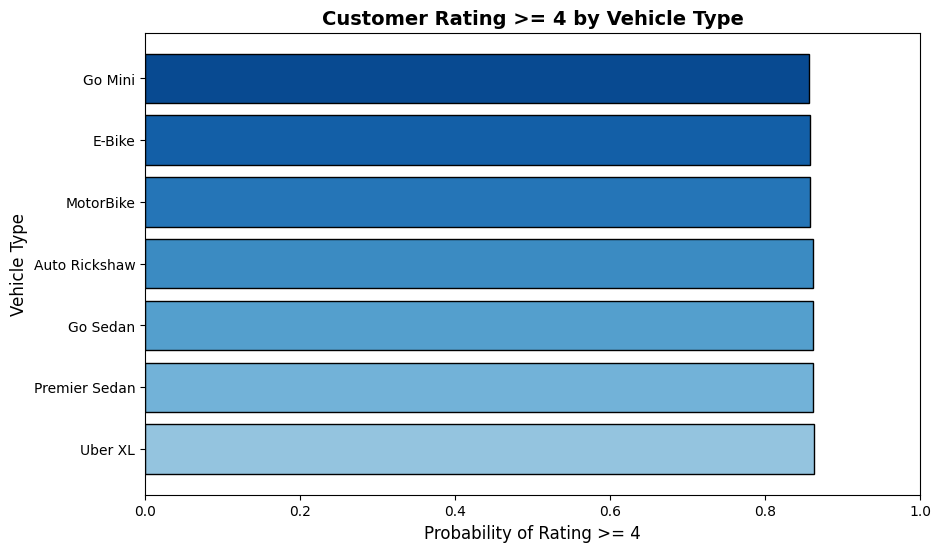

In [16]:
#Customer rating >=4 by Vehicle type
plt.figure(figsize=(10, 6))
plt.barh(prob_by_vehicle.index, prob_by_vehicle.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(prob_by_vehicle))), edgecolor="black")
plt.xlabel("Probability of Rating >= 4", fontsize=12)
plt.ylabel("Vehicle Type", fontsize=12)
plt.title("Customer Rating >= 4 by Vehicle Type", fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.show()

37500
93000
19500


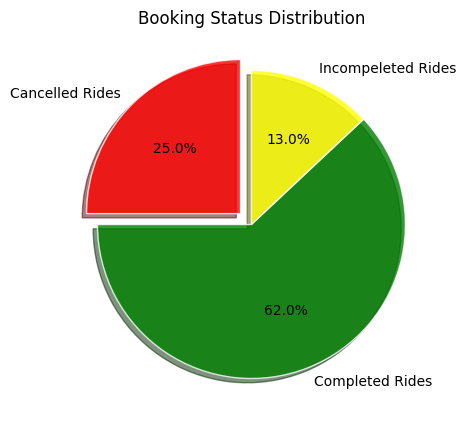

In [17]:
#Calculating Completed, Incompleted or Cancelled rides
Cncls_rides_ttl=ttl_cncld
Comp_rides_ttl = df['Booking Status'].isin(['Completed']).sum()
incomp_rides_ttl = df['Booking Status'].isin(['No Driver Found', 'Incomplete']).sum()
print(Cncls_rides_ttl)
print(Comp_rides_ttl)
print(incomp_rides_ttl)


#Visualizing Completed ,Incompleted & Cancelled Rides
labels=['Cancelled Rides','Completed Rides','Incompeleted Rides']
Values=[Cncls_rides_ttl,Comp_rides_ttl,incomp_rides_ttl]
color=['Red', 'Green', 'Yellow']
x=[0.1,0,0]

plt.figure(figsize=(5,5))
plt.pie(Values,labels=labels,autopct='%1.1f%%',colors=color,shadow=True,wedgeprops={'edgecolor': 'white','alpha':0.8},startangle=90,explode=x)
plt.title('Booking Status Distribution')
plt.show()

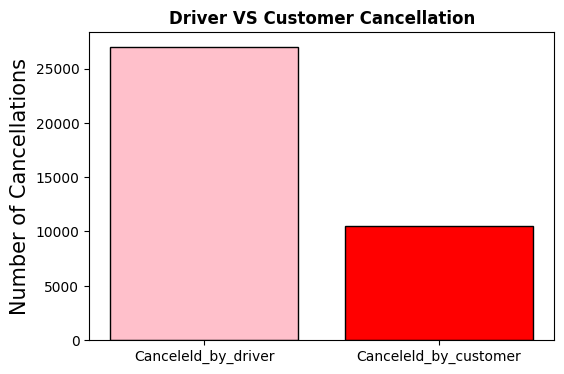

In [18]:
#Shows Driver cancellation vs Customer cancellation

Canceleld_by_driver=df['Booking Status'].isin(['Cancelled by Driver']).sum()
Canceleld_by_customer=df['Booking Status'].isin(['Cancelled by Customer']).sum()
labels=['Canceleld_by_driver','Canceleld_by_customer']
values=[Canceleld_by_driver,Canceleld_by_customer]
plt.figure(figsize=(6,4))
plt.bar(labels,values,color=['pink','red'],edgecolor='black')
plt.ylabel('Number of Cancellations',size=15)
plt.title('Driver VS Customer Cancellation', fontweight='bold')
plt.show()


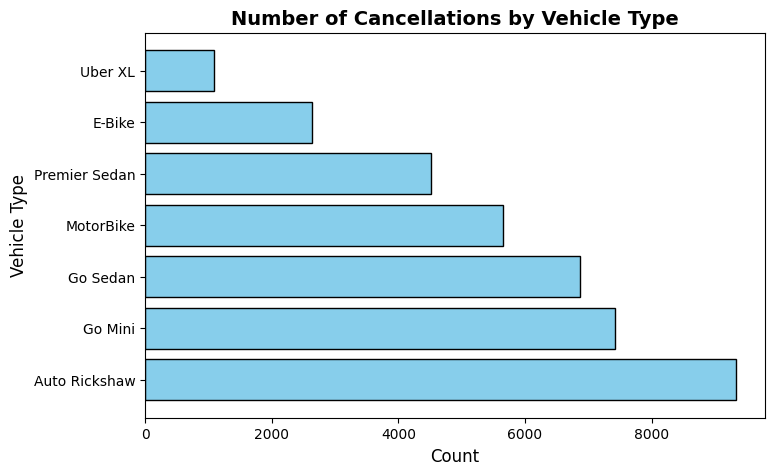

In [19]:
#Shows count of cancellation by Vehicle Type

cancelled_df = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])]
vehicle_counts = cancelled_df['Vehicle Type'].value_counts()
plt.figure(figsize=(8, 5))
plt.barh(vehicle_counts.index, vehicle_counts.values, color="skyblue", edgecolor="black")
plt.title('Number of Cancellations by Vehicle Type', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Vehicle Type', fontsize=12)
plt.show()

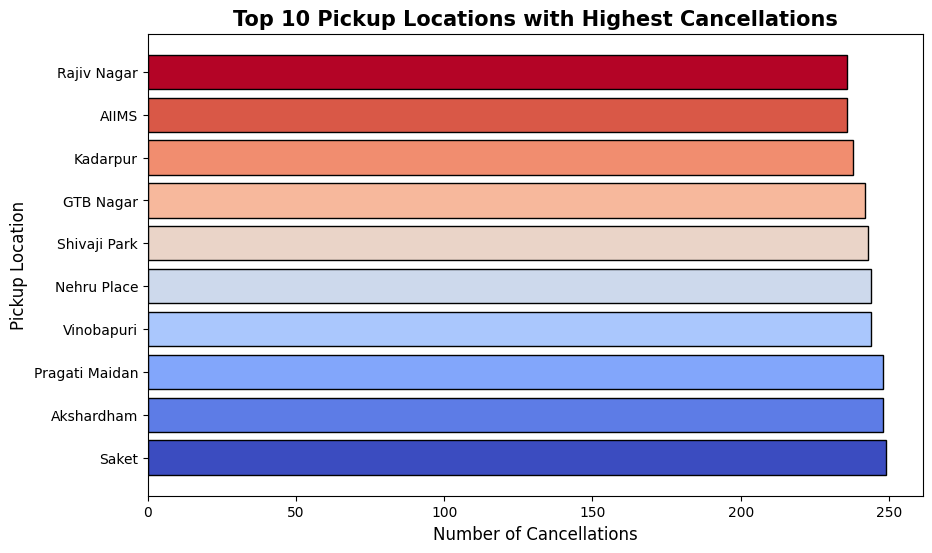

In [20]:
#Shows Top 10 Pickup locations by highest cancellation

cancelled_df = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])]
pickup_counts = cancelled_df['Pickup Location'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(pickup_counts.index, pickup_counts.values, color=plt.cm.coolwarm(np.linspace(0, 1, 10)), edgecolor="black")
plt.title("Top 10 Pickup Locations with Highest Cancellations", fontsize=15, fontweight='bold')
plt.xlabel("Number of Cancellations", fontsize=12)
plt.ylabel("Pickup Location", fontsize=12)
plt.show()

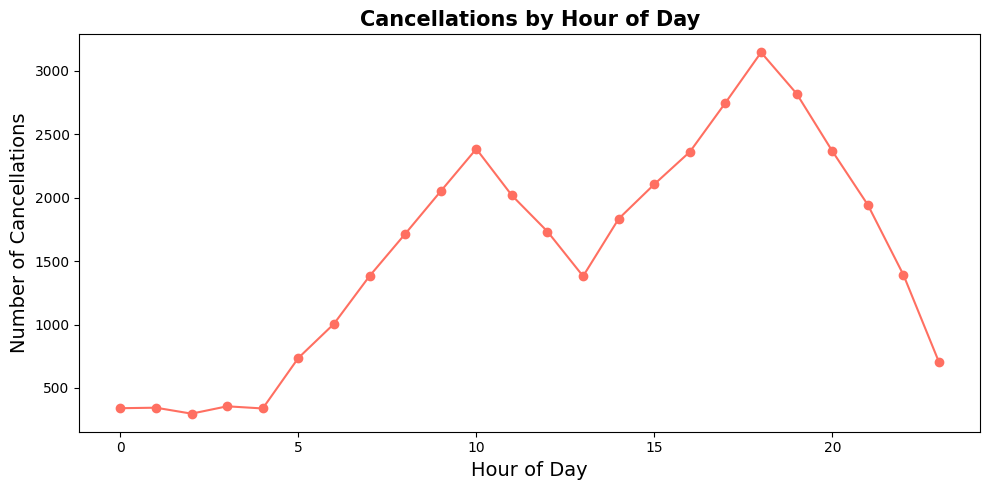

In [21]:
#Shows count of cancelation by Hour of the day

df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
cancelled_df = df[df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])]
cancelled_by_hour = cancelled_df.groupby('Hour').size()
plt.figure(figsize=(10, 5))
plt.plot(cancelled_by_hour.index, cancelled_by_hour.values, marker='o', color='#FF6F61')
plt.title("Cancellations by Hour of Day", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Number of Cancellations", fontsize=14)
plt.tight_layout()
plt.show()


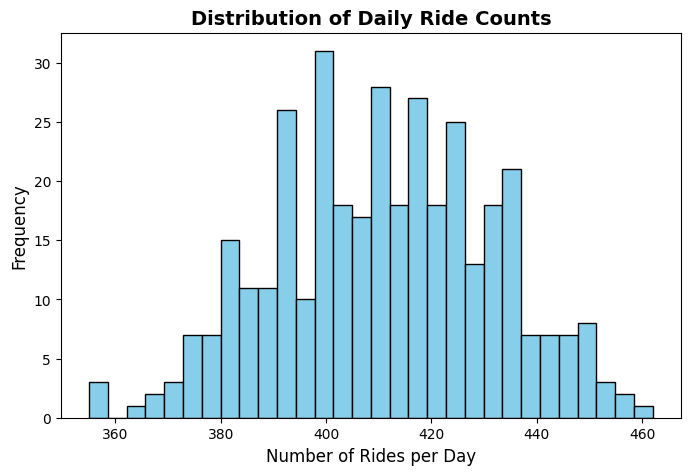

In [22]:
# Distribution of Daily Ride Counts
rides_per_day = df.groupby(df['Date']).size().reset_index()
rides_per_day.columns = ['Date', 'Ride_Count']
plt.figure(figsize=(8, 5))
plt.hist(rides_per_day['Ride_Count'], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Daily Ride Counts", fontsize=14, fontweight='bold')
plt.xlabel("Number of Rides per Day", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

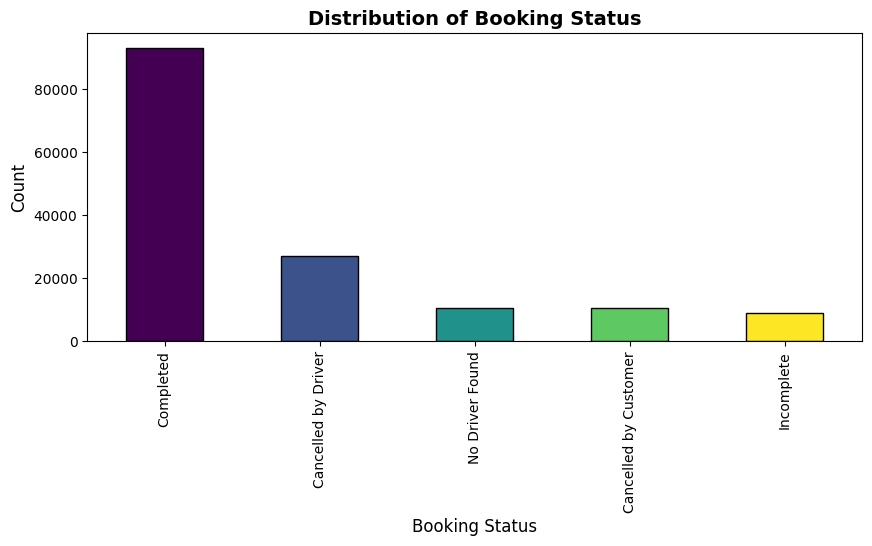

In [23]:
#Distribution of Booking Status
plt.figure(figsize=(10, 4))
df['Booking Status'].value_counts().plot(kind="bar",color=plt.cm.viridis(np.linspace(0, 1, df['Booking Status'].nunique())),edgecolor="black")
plt.xlabel("Booking Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Booking Status", fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_1555/914324975.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(customer_reasons.index,rotation=79)
/tmp/ipykernel_1555/914324975.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(driver_reasons.index,rotation=79)


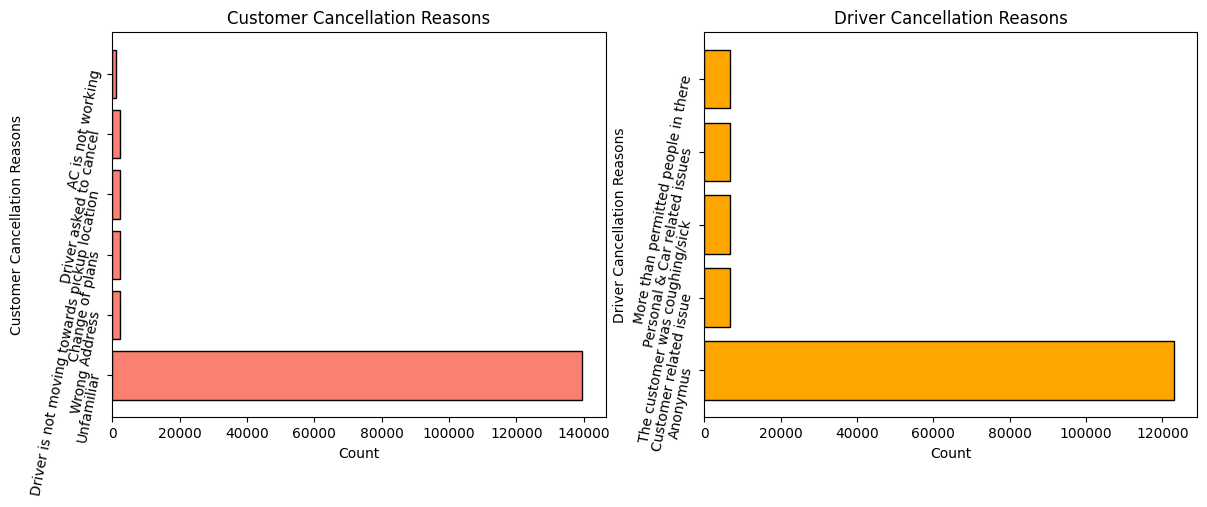

In [24]:
# Cancellation Reasons (Customer & Driver)
customer_reasons = df['Reason for cancelling by Customer'].value_counts()
driver_reasons = df['Driver Cancellation Reason'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(customer_reasons.index, customer_reasons.values, color="salmon", edgecolor="black")
axes[0].set_title("Customer Cancellation Reasons")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Customer Cancellation Reasons")
axes[0].set_yticklabels(customer_reasons.index,rotation=79)
axes[1].barh(driver_reasons.index, driver_reasons.values, color="orange", edgecolor="black")
axes[1].set_title("Driver Cancellation Reasons")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Driver Cancellation Reasons")
axes[1].set_yticklabels(driver_reasons.index,rotation=79)
plt.show()

                 Model  Accuracy (%)
0  Logistic Regression         93.01
1        Decision Tree        100.00
2        Random Forest        100.00
3          Naive Bayes        100.00
4                  KNN         97.96
5              XGBoost        100.00


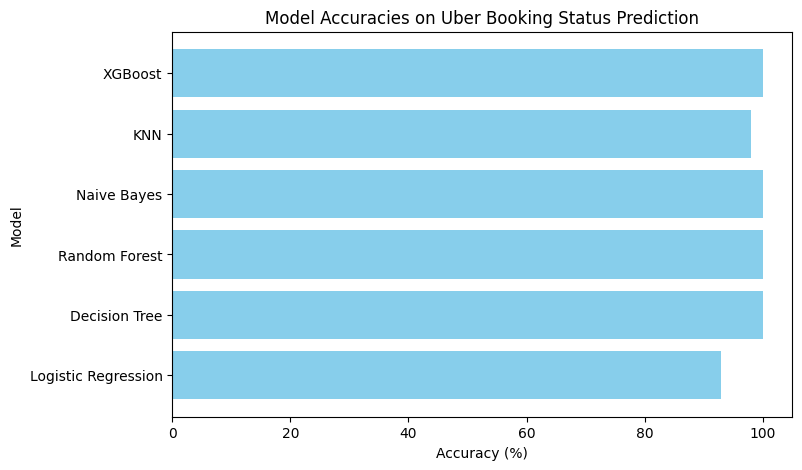

In [25]:
# Convert date and time to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

# Extract useful date & time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Time'].dt.hour
df['Minute'] = df['Time'].dt.minute

# Drop original date/time columns
df = df.drop(columns=['Date', 'Time'])

# Fill missing values
df = df.fillna("Unknown")

# Encode categorical variables
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object' or isinstance(df[col].iloc[0], str):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Define features & target
target_col = "Booking Status"
X = df.drop(target_col, axis=1)
y = df[target_col]

# Scale numeric features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models (WITHOUT SVM)
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Try importing XGBoost if available
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(eval_metric='mlogloss')
except ImportError:
    print("XGBoost not installed, skipping...")

# Train & evaluate
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracies[name] = round(acc, 2)

# Show results
results_df = pd.DataFrame(list(accuracies.items()), columns=["Model", "Accuracy (%)"])
print(results_df)

# Plot bar chart with matplotlib (no seaborn)
plt.figure(figsize=(8,5))
plt.barh(results_df["Model"], results_df["Accuracy (%)"], color="skyblue")
plt.title("Model Accuracies on Uber Booking Status Prediction")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.show()